In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/survey_data_labelled.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.columns 

Index(['Age', 'Gender', 'Occupation', 'Device_Type', 'Work_Productivity_Score',
       'Weekend_Screen_Time_Hours', 'Daily_Phone_Hours', 'Sleep_Hours',
       'Social_Media_Hours', 'Stress_Level', 'Caffeine_Intake_Cups'],
      dtype='object')

<h3> Irrelevant Columns

In [5]:
irrelevant = []

In [6]:
df = df.drop(columns=irrelevant)

<h3> Encoding Target Variable </h3>

In [7]:
le = LabelEncoder()
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [8]:
df.Stress_Level.value_counts()

Stress_Level
0    29
2    21
1     6
Name: count, dtype: int64

In [9]:
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

In [10]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={0: 100, 1: 100, 2: 100},  # <-- specify per class
    k_neighbors=2,
    random_state=42
)

In [28]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [29]:
X_train_scaled.shape

(39, 11)

In [30]:
X_train_smote.shape

(300, 11)

<h3> Logistic Regression Training 

In [31]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_smote, y_train_smote)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [32]:
y_pred_log = log_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [33]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.4117647058823529
              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.17      0.50      0.25         2
           2       0.50      0.33      0.40         6

    accuracy                           0.41        17
   macro avg       0.41      0.43      0.38        17
weighted avg       0.50      0.41      0.44        17



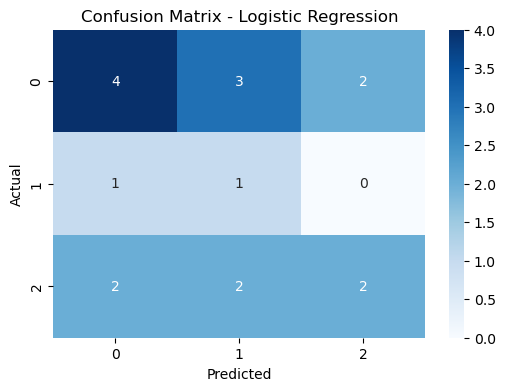

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()